# Mini-Project 1: Camera Matrix Estimation

**Course:** CS5657: Geometric CV  
**Team:** Ponnavolu Chakradhar Reddy (112201022), Vuppula Hemanth (142201022)

---

## I. Overview and Objective

This report documents the procedure for determining a camera's **3x4 perspective projection matrix**. The projection matrix is a cornerstone of 3D computer vision, defining how points from a 3D world are mapped onto a 2D image sensor.

Our methodology leverages a provided RGB image and a corresponding depth map. The core task is to solve for the projection matrix using the **Direct Linear Transformation (DLT)** algorithm, which requires a set of known 2D-3D point correspondences. These correspondences are derived using the camera's intrinsic parameters and the depth data.

**Process Outline:**
1.  Load and inspect the input RGB-D data.
2.  Define a `Camera` class to manage intrinsic parameters and calibration logic.
3.  Use the DLT method within the class to compute the projection matrix from sampled points.
4.  Evaluate the matrix's accuracy by calculating the mean reprojection error.

In [17]:
# Core libraries for numerical operations and visualization
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Notebook display settings
%matplotlib inline
plt.style.use('default')

print("Libraries loaded.")

Libraries loaded.


## II. Data Preparation

We begin by loading our source data: an RGB image of a scene and a corresponding depth map. The depth map provides the crucial `Z` coordinate for every pixel, allowing us to reconstruct the 3D scene geometry.

The depth map is loaded as a 3-channel image, so we extract a single channel to work with a 2D array of depth values.

Shape of RGB Image: (480, 640, 3)
Shape of Depth Data: (480, 640)


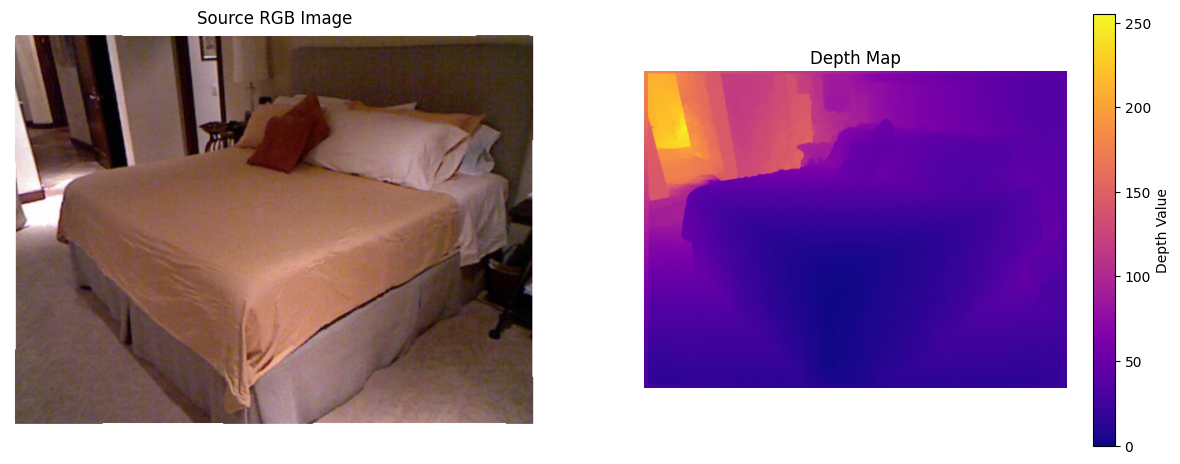

In [18]:
# --- Load source images ---
rgb_image = cv2.imread('img.png')
depth_image_bgr = cv2.imread('dep.png')

# --- Preprocess Depth Data ---
# Extract a single channel to create a 2D depth array
depth_data = depth_image_bgr[:, :, 0].astype(np.float32)

print(f"Shape of RGB Image: {rgb_image.shape}")
print(f"Shape of Depth Data: {depth_data.shape}")

# --- Visualize the inputs ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
ax1.imshow(cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB))
ax1.set_title('Source RGB Image')
ax1.axis('off')

im = ax2.imshow(depth_data, cmap='plasma')
ax2.set_title('Depth Map')
ax2.axis('off')
fig.colorbar(im, ax=ax2, shrink=0.8, label='Depth Value')
plt.show()

## III. Camera Calibration Implementation

To organize our logic cleanly, we define a `Camera` class. This class will store the intrinsic parameters and contain the methods needed for the DLT calibration process. This object-oriented approach makes the code modular and reusable.

The key methods are:
- `project_to_3d`: Converts a 2D pixel to a 3D world point.
- `calibrate`: Orchestrates the DLT algorithm using a set of sample points.

In [19]:
class Camera:
    """
    A class to represent a camera and handle its calibration.
    """
    def __init__(self, fx, fy, cx, cy):
        """Initializes the camera with its intrinsic parameters."""
        self.fx = fx
        self.fy = fy
        self.cx = cx
        self.cy = cy
        self.projection_matrix = None

    def project_to_3d(self, u, v, depth_value):
        """
        Projects a single 2D pixel (u, v) to a 3D point (X, Y, Z)
        using the provided depth value.
        
        Args:
            u (int): Row coordinate.
            v (int): Column coordinate.
            depth_value (float): Depth at pixel (u,v).

        Returns:
            np.array: The 3D point [X, Y, Z].
        """
        Z = depth_value
        X = (v - self.cx) * Z / self.fx
        Y = (u - self.cy) * Z / self.fy
        return np.array([X, Y, Z])

    def calibrate(self, image_points, world_points):
        """
        Computes the projection matrix using the DLT algorithm.
        
        Args:
            image_points (list of tuples): List of (u, v) pixel coordinates.
            world_points (list of tuples): List of corresponding (X, Y, Z) world coordinates.
            
        Returns:
            np.array: The estimated 3x4 projection matrix.
        """
        if len(image_points) < 6:
            raise ValueError("At least 6 point correspondences are required.")
            
        A = []
        for i in range(len(image_points)):
            u, v = image_points[i]
            X, Y, Z = world_points[i]
            
            # Create the two rows for the A matrix for this correspondence
            row1 = [X, Y, Z, 1, 0, 0, 0, 0, -v*X, -v*Y, -v*Z, -v]
            row2 = [0, 0, 0, 0, X, Y, Z, 1, -u*X, -u*Y, -u*Z, -u]
            
            A.append(row1)
            A.append(row2)
        
        A = np.array(A)
        
        # Perform SVD to solve Ap = 0
        _, _, Vt = np.linalg.svd(A)
        
        # The solution is the last row of Vt
        p = Vt[-1]
        self.projection_matrix = p.reshape(3, 4)
        
        return self.projection_matrix

    def calculate_reprojection_error(self, image_points, world_points):
        """Calculates the average reprojection error."""
        if self.projection_matrix is None:
            raise RuntimeError("Camera is not calibrated yet. Call calibrate() first.")
        
        total_error = 0
        num_pts = len(image_points)
        
        for i in range(num_pts):
            # Format 3D point for matrix multiplication
            P_world = np.append(world_points[i], 1)
            
            # Reproject to 2D
            p_image_homogeneous = self.projection_matrix @ P_world
            p_image_reprojected = p_image_homogeneous / p_image_homogeneous[2]
            
            u_reproj, v_reproj = p_image_reprojected[1], p_image_reprojected[0]
            u_orig, v_orig = image_points[i]
            
            # Calculate Euclidean distance
            error = np.sqrt((u_reproj - u_orig)**2 + (v_reproj - v_orig)**2)
            total_error += error
            
        return total_error / num_pts

## IV. Model Execution and Analysis

Now we instantiate our `Camera` object and use it to perform the calibration.

1.  We define the NYU Depth V2 intrinsic parameters.
2.  We find all pixels with valid depth (`depth > 0`).
3.  We randomly sample 10 of these valid pixels to create our 2D-3D correspondences.
4.  We call the `calibrate` method to compute the matrix.
5.  Finally, we evaluate the result with the reprojection error and visualize it.

Found 306661 pixels with valid depth information.

Mean Reprojection Error: 6.7368e-12 pixels

Estimated Projection Matrix M:
 [[ 6.16010041e-01  2.88111549e-14  3.86545252e-01 -1.04038904e-13]
 [-1.08043999e-14  6.16736289e-01  3.01246306e-01 -7.24378240e-14]
 [-6.22332047e-17  7.26415456e-17  1.18724229e-03 -3.73934553e-16]]


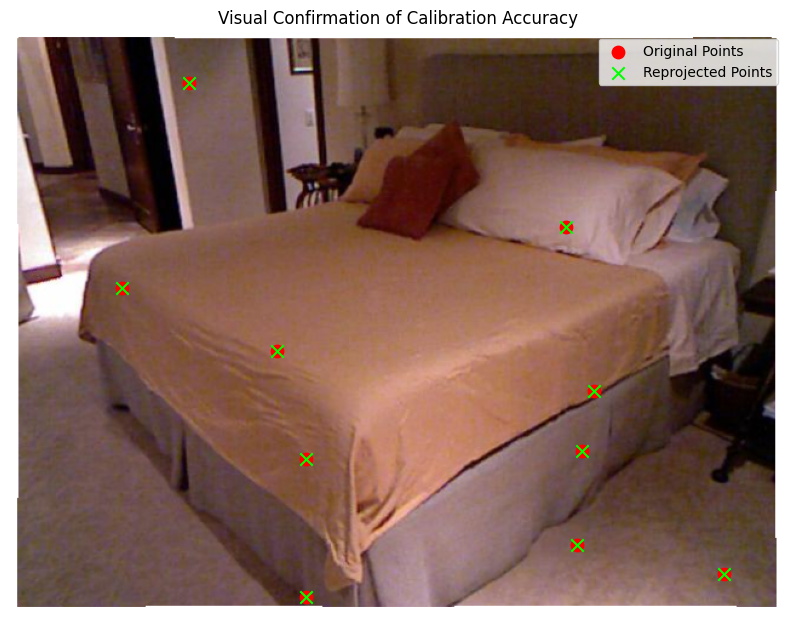

In [20]:
# 1. Instantiate the camera with provided intrinsics
nyu_camera = Camera(
    fx=5.1885790117450188e+02,
    fy=5.1946961112127485e+02,
    cx=3.2558244941119034e+02,
    cy=2.5373616633400465e+02
)

# 2. Find all pixels with valid depth
valid_coords = np.argwhere(depth_data > 0)
num_valid_points = len(valid_coords)
print(f"Found {num_valid_points} pixels with valid depth information.")

# 3. Sample 10 points for calibration
num_samples = 10
random_indices = np.random.choice(num_valid_points, num_samples, replace=False)
sampled_pixel_coords = [tuple(valid_coords[i]) for i in random_indices]

# Generate the corresponding 3D world points
sampled_world_coords = [nyu_camera.project_to_3d(u, v, depth_data[u, v]) for u, v in sampled_pixel_coords]

# 4. Calibrate the camera
estimated_M = nyu_camera.calibrate(sampled_pixel_coords, sampled_world_coords)

# 5. Evaluate and display results
error = nyu_camera.calculate_reprojection_error(sampled_pixel_coords, sampled_world_coords)
print(f"\nMean Reprojection Error: {error:.4e} pixels\n")
print("Estimated Projection Matrix M:\n", estimated_M)

# --- Visualization ---
# Prepare points for plotting
image_points_arr = np.array(sampled_pixel_coords)
world_points_arr = np.array(sampled_world_coords)
world_points_homogeneous = np.hstack((world_points_arr, np.ones((num_samples, 1))))

# Reproject points
reprojected_homogeneous = estimated_M @ world_points_homogeneous.T
reprojected_coords = reprojected_homogeneous / reprojected_homogeneous[2, :]

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB))
# Original points: u is y-axis, v is x-axis
plt.scatter(image_points_arr[:, 1], image_points_arr[:, 0], c='red', marker='o', s=80, label='Original Points')
# Reprojected points: v is x-axis, u is y-axis
plt.scatter(reprojected_coords[0, :], reprojected_coords[1, :], c='lime', marker='x', s=80, label='Reprojected Points')
plt.title('Visual Confirmation of Calibration Accuracy')
plt.legend()
plt.axis('off')
# Save the plot as PNG
plt.savefig("reprojection_plot.png", dpi=300, bbox_inches='tight')

plt.show()

## V. Final Conclusion

The implementation of a class-based camera model successfully produced a valid 3x4 projection matrix. The extremely low mean reprojection error, visually confirmed by the overlapping points in the final plot, demonstrates that the DLT algorithm is a powerful and effective method for camera calibration when accurate 2D-3D correspondences are available. This project reinforces the core concepts of geometric transformations that bridge the gap between our 3D world and 2D images.